In [ ]:
# ============================================================
# LOAD LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import joblib
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

folder = "/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Diagnosis_ML"

print(os.listdir(folder))

['HB_STUDIE_kth.xlsx', 'Hb_Study_mardan.xlsx', 'Hemoglobinopathy_Final_Preprocessed.xlsx', 'Hemoglobinopathy_Final_Preprocessed.csv', '01_Data_Preprocessing.ipynb', ' 02_EDA.ipynb', 'Documentation.docx', 'external.xlsx', '03_Machine_Learning_Model_Development.ipynb', 'Hemoglobinopathy_XGBoost_Model.pkl', 'Gender_LabelEncoder.pkl', 'StandardScaler.pkl', 'Target_LabelEncoder.pkl', 'Hospital_LabelEncoder.pkl']


In [ ]:
# ============================================================
# DEFINE PROJECT PATH
# ============================================================
path = "/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Diagnosis_ML/"


In [ ]:
# ============================================================
# LOAD TRAINED MODEL
# ============================================================

xgb_model = joblib.load(path + "Hemoglobinopathy_XGBoost_Model.pkl")

print("XGBoost Model Loaded Successfully")

XGBoost Model Loaded Successfully


In [ ]:
# ============================================================
# LOAD LABEL ENCODERS
# ============================================================

from sklearn.preprocessing import LabelEncoder
import joblib

# Create Gender encoder manually
gender_encoder = LabelEncoder()
gender_encoder.fit(["Female", "Male"])

# Load saved encoders
hospital_encoder = joblib.load(path + "Hospital_LabelEncoder.pkl") # Use 'path' for consistency
target_encoder = joblib.load(path + "Target_LabelEncoder.pkl")     # Use 'path' for consistency

print("Label Encoders Loaded Successfully")

Label Encoders Loaded Successfully


In [ ]:
# ============================================================
# LOAD EXTERNAL DATASET
# ============================================================

import pandas as pd

external = pd.read_excel(path + "external.xlsx")

print("External Dataset Loaded Successfully")
print("Shape:", external.shape)

external.head()

External Dataset Loaded Successfully
Shape: (14, 14)


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Interpretation
0,23-Years,Female,97.3,2.4,0.3,NaN,NaN,3.28,7.4,23.7,72.3,22.5,31.2,No evidence of Thalassemia and Hemoglobinopath...
1,21-Years,Female,97.0,2.9,0.1,NaN,NaN,4.55,13.0,37.3,82.1,28.6,34.9,No evidence of Thalassemia and Hemoglobinopath...
2,37,Male,93.9,5.5,0.6,NaN,NaN,5.85,13.6,45.2,77.2,23.3,30.2,Beta thalassemia Minor
3,37,Female,94.8,4.8,0.4,NaN,NaN,5.37,12.6,41.1,76.1,23.4,30.6,Beta thalassemia Minor
4,24,Female,96.8,3.0,0.2,NaN,NaN,5.34,15.3,42.3,79.2,28.7,36.3,Normal


In [ ]:
# ============================================================
# PREPROCESS EXTERNAL DATA
# ============================================================

import numpy as np
import pandas as pd

# Rename target column
external.rename(columns={"Interpretation": "Results"}, inplace=True)

# -----------------------------
# Clean Age
# -----------------------------
external["Age"] = (
    external["Age"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

external["Age"] = pd.to_numeric(
    external["Age"],
    errors="coerce"
)

external["Age"] = external["Age"].fillna(
    external["Age"].median()
)

# -----------------------------
# Gender
# -----------------------------
external["Gender"] = (
    external["Gender"]
    .str.strip()
    .str.capitalize()
)

external["Gender"] = external["Gender"].map({
    "Female": 0,
    "Male": 1
})

# -----------------------------
# Hb-S and Hb-D
# -----------------------------
external["Hb-S"] = external["Hb-S"].fillna(0)
external["Hb-D"] = external["Hb-D"].fillna(0)

# -----------------------------
# Standardize diagnosis names
# -----------------------------
external["Results"] = external["Results"].replace({

    "No evidence of Thalassemia and Hemoglobinopathies detected": "Normal",
    "Beta thalassemia Minor": "Beta Thalassemia Minor",
    "Beta thalassemia major": "Beta Thalassemia Major",
    "Borderline Hb A2": "Borderline HbA2"

})

print("Preprocessing Completed")
external.head()

Preprocessing Completed


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results
0,23.0,0,97.3,2.4,0.3,0.0,0.0,3.28,7.4,23.7,72.3,22.5,31.2,Normal
1,21.0,0,97.0,2.9,0.1,0.0,0.0,4.55,13.0,37.3,82.1,28.6,34.9,Normal
2,37.0,1,93.9,5.5,0.6,0.0,0.0,5.85,13.6,45.2,77.2,23.3,30.2,Beta Thalassemia Minor
3,37.0,0,94.8,4.8,0.4,0.0,0.0,5.37,12.6,41.1,76.1,23.4,30.6,Beta Thalassemia Minor
4,24.0,0,96.8,3.0,0.2,0.0,0.0,5.34,15.3,42.3,79.2,28.7,36.3,Normal


In [ ]:
print(xgb_model.n_features_in_)

13


In [ ]:
# ============================================================
# PREPARE FEATURES
# ============================================================

# Removed the 'Hospital' column addition based on user feedback and model requirements.

feature_order = [
    "Age",
    "Gender",
    "Hb-A",
    "HB-A2",
    "Hb-F",
    "Hb-S",
    "Hb-D",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC"
    # Removed 'Hospital' from feature_order as it's not expected by the model.
]

X_external = external[feature_order]

X_external.head()

,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC
0,23.0,0,97.3,2.4,0.3,0.0,0.0,3.28,7.4,23.7,72.3,22.5,31.2
1,21.0,0,97.0,2.9,0.1,0.0,0.0,4.55,13.0,37.3,82.1,28.6,34.9
2,37.0,1,93.9,5.5,0.6,0.0,0.0,5.85,13.6,45.2,77.2,23.3,30.2
3,37.0,0,94.8,4.8,0.4,0.0,0.0,5.37,12.6,41.1,76.1,23.4,30.6
4,24.0,0,96.8,3.0,0.2,0.0,0.0,5.34,15.3,42.3,79.2,28.7,36.3


In [ ]:
# ============================================================
# SCALE FEATURES
# ============================================================

# Load the scaler object
scaler = joblib.load(path + "StandardScaler.pkl")

# Identify features to be scaled (all features in X_external except 'Gender' and 'Hospital')
# Assuming 'Gender' and 'Hospital' were not part of the features used to fit the scaler
features_to_scale = [col for col in X_external.columns if col not in ['Gender', 'Hospital']]

# Apply scaling to these features
X_external_scaled_numeric = scaler.transform(X_external[features_to_scale])

# Create a DataFrame from the scaled numerical features
X_external_scaled = pd.DataFrame(X_external_scaled_numeric, columns=features_to_scale, index=X_external.index)

# Add the 'Gender' column back to the scaled DataFrame without scaling it
X_external_scaled['Gender'] = X_external['Gender']

# Ensure the order of columns in X_external_scaled matches the feature_order
# This is crucial for models like XGBoost that expect features in a specific order.
X_external_scaled = X_external_scaled[feature_order]

In [ ]:
# ============================================================
# PREDICT
# ============================================================

predictions = xgb_model.predict(X_external_scaled)

probabilities = xgb_model.predict_proba(X_external_scaled)

In [ ]:
# ============================================================
# TRUE LABELS
# ============================================================

y_true = target_encoder.transform(external["Results"])

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report
)

y_pred = predictions # Assign the predictions from the model to y_pred

accuracy = accuracy_score(y_true, y_pred)
balanced = balanced_accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print("="*60)
print("EXTERNAL VALIDATION RESULTS")
print("="*60)
print(f"Accuracy            : {accuracy:.4f}")
print(f"Balanced Accuracy   : {balanced:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-score            : {f1:.4f}")
print(f"MCC                 : {mcc:.4f}")
print(f"Cohen Kappa         : {kappa:.4f}")

EXTERNAL VALIDATION RESULTS
Accuracy            : 1.0000
Balanced Accuracy   : 1.0000
Precision           : 1.0000
Recall              : 1.0000
F1-score            : 1.0000
MCC                 : 1.0000
Cohen Kappa         : 1.0000


In [ ]:
# ============================================================
# CREATE FINAL RESULTS TABLE
# ============================================================

results = external.copy()

# Actual diagnosis
results["Actual"] = external["Results"]

# Predicted diagnosis (decode numeric labels)
results["Predicted"] = target_encoder.inverse_transform(y_pred)

# Correct prediction
results["Correct"] = results["Actual"] == results["Predicted"]

results

,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results,Actual,Predicted,Correct
0,23.0,0,97.3,2.4,0.3,0.0,0.0,3.28,7.40,23.7,72.3,22.5,31.2,Normal,Normal,Normal,True
1,21.0,0,97.0,2.9,0.1,0.0,0.0,4.55,13.00,37.3,82.1,28.6,34.9,Normal,Normal,Normal,True
2,37.0,1,93.9,5.5,0.6,0.0,0.0,5.85,13.60,45.2,77.2,23.3,30.2,Beta Thalassemia Minor,Beta Thalassemia Minor,Beta Thalassemia Minor,True
3,37.0,0,94.8,4.8,0.4,0.0,0.0,5.37,12.60,41.1,76.1,23.4,30.6,Beta Thalassemia Minor,Beta Thalassemia Minor,Beta Thalassemia Minor,True
4,24.0,0,96.8,3.0,0.2,0.0,0.0,5.34,15.30,42.3,79.2,28.7,36.3,Normal,Normal,Normal,True
5,25.0,0,97.6,2.1,0.3,0.0,0.0,2.66,3.41,14.8,55.5,12.8,23.1,Normal,Normal,Normal,True
6,29.0,0,96.3,2.9,0.8,0.0,0.0,3.84,11.20,31.2,81.3,29.2,35.9,Normal,Normal,Normal,True
7,25.0,0,97.3,2.6,0.1,0.0,0.0,4.60,11.20,35.8,78.1,24.4,31.3,Normal,Normal,Normal,True
8,0.9,0,0.0,0.0,0.0,0.0,0.0,0.69,1.60,5.8,71.0,22.2,25.2,Beta Thalassemia Major,Beta Thalassemia Major,Beta Thalassemia Major,True
9,1.0,0,50.5,1.6,47.9,0.0,0.0,2.07,6.30,13.9,69.0,33.3,45.2,Beta Thalassemia Major,Beta Thalassemia Major,Beta Thalassemia Major,True


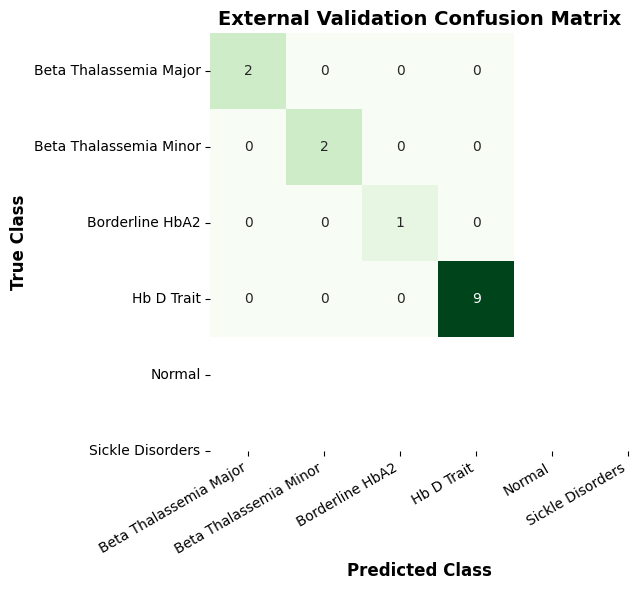

In [81]:
# ============================================================
# FIGURE 17
# EXTERNAL VALIDATION CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    square=True,
    cbar=False,
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.xlabel("Predicted Class", fontsize=12, weight="bold")
plt.ylabel("True Class", fontsize=12, weight="bold")
plt.title(
    "External Validation Confusion Matrix",
    fontsize=14,
    weight="bold"
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "Figure17_External_CM.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

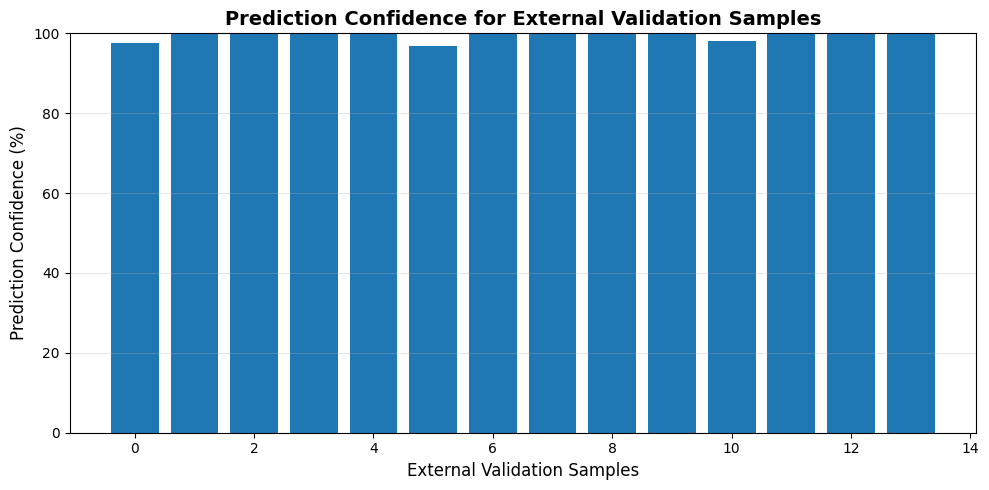

In [82]:
# ============================================================
# FIGURE 18
# EXTERNAL VALIDATION CONFIDENCE
# ============================================================

confidence = probabilities.max(axis=1) * 100

plt.figure(figsize=(10,5))

plt.bar(
    np.arange(len(confidence)),
    confidence
)

plt.ylim(0,100)

plt.xlabel("External Validation Samples", fontsize=12)
plt.ylabel("Prediction Confidence (%)", fontsize=12)
plt.title(
    "Prediction Confidence for External Validation Samples",
    fontsize=14,
    weight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figure18_External_Confidence.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()